# CC26-PSU384

**Proyek:** Sistem Klasifikasi Sampah Otomatis Berbasis Gambar dengan AI  
**Tim AI:** Naswa Resaptania Zhulvan & Raffi Dewangga Susanto  

| Kelas | Deskripsi | Train | Val | Test |
|-------|-----------|-------|-----|------|
| Kaca | Botol kaca, gelas, cermin | 514 | 110 | 112 |
| Kardus | Kardus, kotak kemasan | 561 | 121 | 121 |
| Kertas | Koran, buku, kertas | 631 | 136 | 136 |
| Logam | Kaleng, besi, aluminium | 637 | 137 | 138 |
| Plastik | Botol, kantong plastik | 612 | 131 | 133 |
| Residu | Sampah tak dapat didaur ulang | 485 | 104 | 106 |



## Setup & Upload Dataset


In [2]:
# Install library
!pip install -q anthropic seaborn scikit-learn fastapi uvicorn python-multipart nest-asyncio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 763.1/763.1 kB 22.8 MB/s eta 0:00:00


In [4]:
# Upload dataset
from google.colab import files
import zipfile, os, shutil

print("Pilih file dataset")
uploaded = files.upload()

zip_name = list(uploaded.keys())[0]
print(f"\n{zip_name}...")
with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall('/content/dataset')

# Cek struktur folder
for split in ['train', 'validation', 'test']:
    path = f'/content/dataset/{split}'
    if os.path.exists(path):
        classes = os.listdir(path)
        total = sum(len(os.listdir(f'{path}/{c}')) for c in classes if os.path.isdir(f'{path}/{c}'))
        print(f"  {split:10s}: {total:4d} gambar | {len(classes)} kelas")

print("\nSiap digunakan")
DATA_DIR = '/content/dataset'


Pilih file dataset


Saving dataset_final.zip to dataset_final.zip

dataset_final.zip...
  train     : 3434 gambar | 6 kelas
  validation:  733 gambar | 6 kelas
  test      :  740 gambar | 6 kelas

Siap digunakan


In [6]:
import os

print(os.listdir('/content'))
print(os.listdir('/content/dataset'))

['.config', 'dataset_final.zip', 'saved_models', 'dataset', 'logs', 'evaluation', 'sample_data']
['validation', 'train', 'test']


## Konfigurasi Global


In [7]:
# Konstanta & Konfigurasi
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset
DATA_DIR    = '/content/dataset'
CLASS_NAMES = ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']
NUM_CLASSES = len(CLASS_NAMES)

# Model
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42

# Phase 1 (frozen base)
PHASE1_EPOCHS = 15
PHASE1_LR     = 1e-3

# Phase 2 (fine-tune)
PHASE2_EPOCHS    = 20
PHASE2_LR        = 1e-5
FINETUNE_LAYERS  = 30

# Paths
MODEL_DIR = '/content/saved_models'
LOG_DIR   = '/content/logs'
EVAL_DIR  = '/content/evaluation'
for d in [MODEL_DIR, LOG_DIR, EVAL_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"   Kelas: {CLASS_NAMES}")
print(f"   Input size: {IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")


   Kelas: ['Kaca', 'Kardus', 'Kertas', 'Logam', 'Plastik', 'Residu']
   Input size: (224, 224)
   Batch size: 32


## Data Pipeline & Augmentasi


In [13]:
# Cek isi dataset
import os

print(f"{'Split':12s} {'Kelas':10s} {'Jumlah Gambar':>15s}")

total_per_class = {c: 0 for c in CLASS_NAMES}
for split in ['train', 'validation', 'test']:
    for cls in CLASS_NAMES:
        path = f'{DATA_DIR}/{split}/{cls}'
        if os.path.exists(path):
            n = len(os.listdir(path))
            total_per_class[cls] += n
            print(f"{split:12s} {cls:10s} {n:>15d}")
    print("-" * 40)

print("\nTotal per kelas:")
for cls, total in total_per_class.items():
    print(f"  {cls:8s}: {total:4d}")


Split        Kelas        Jumlah Gambar
train        Kaca                   513
train        Kardus                 560
train        Kertas                 630
train        Logam                  636
train        Plastik                611
train        Residu                 484
----------------------------------------
validation   Kaca                   109
validation   Kardus                 120
validation   Kertas                 135
validation   Logam                  136
validation   Plastik                130
validation   Residu                 103
----------------------------------------
test         Kaca                   111
test         Kardus                 120
test         Kertas                 135
test         Logam                  137
test         Plastik                132
test         Residu                 105
----------------------------------------

Total per kelas:
  Kaca    :  733
  Kardus  :  800
  Kertas  :  900
  Logam   :  909
  Plastik :  873
  Residu  :  6

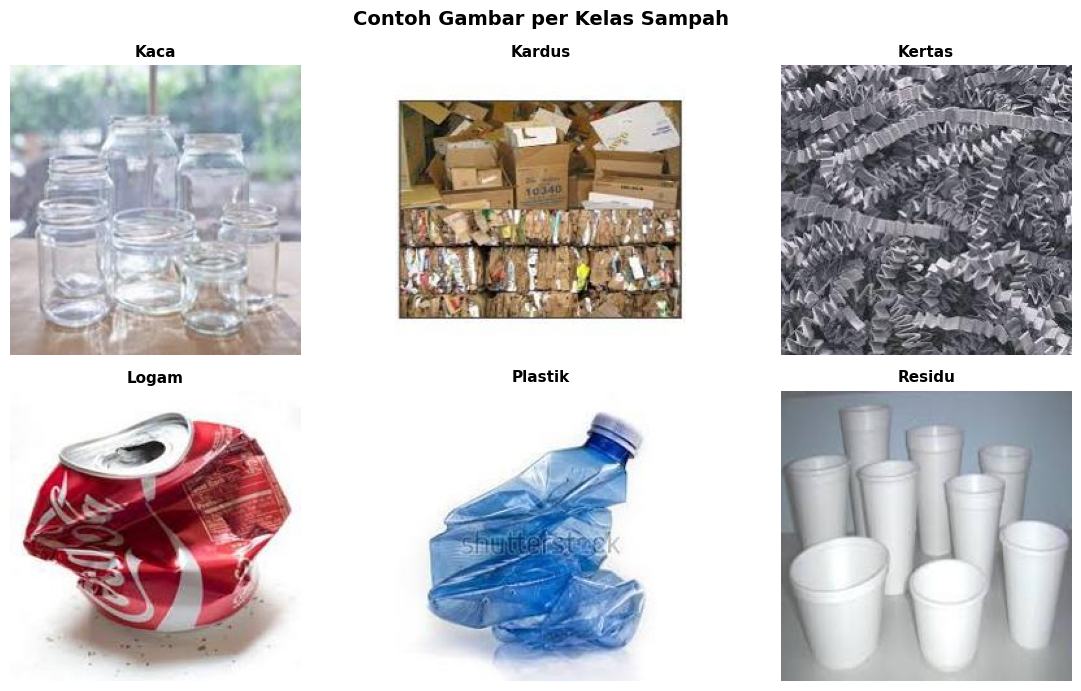

In [14]:
# Visualisasi Contoh Gambar per Kelas
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random, os

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
fig.suptitle('Contoh Gambar per Kelas Sampah', fontsize=14, fontweight='bold')

for ax, cls in zip(axes.flatten(), CLASS_NAMES):
    img_dir = f'{DATA_DIR}/train/{cls}'
    img_file = random.choice(os.listdir(img_dir))
    img = mpimg.imread(f'{img_dir}/{img_file}')
    ax.imshow(img)
    ax.set_title(cls, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(f'{EVAL_DIR}/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()


In [15]:
# Build Dataset Pipeline dengan Augmentasi
import tensorflow as tf

def build_datasets():
    # Augmentasi untuk Training
    augmentation_layer = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomBrightness(factor=0.1),
        tf.keras.layers.RandomContrast(factor=0.1),
    ], name="data_augmentation")

    # Load dari folder
    train_ds = tf.keras.utils.image_dataset_from_directory(
        f'{DATA_DIR}/train',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=CLASS_NAMES,
        shuffle=True,
        seed=SEED
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        f'{DATA_DIR}/validation',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=CLASS_NAMES,
        shuffle=False
    )
    test_ds = tf.keras.utils.image_dataset_from_directory(
        f'{DATA_DIR}/test',
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode='categorical',
        class_names=CLASS_NAMES,
        shuffle=False
    )

    # Preprocessing functions
    def preprocess_train(images, labels):
        images = augmentation_layer(images, training=True)
        images = tf.cast(images, tf.float32) / 255.0
        return images, labels

    def preprocess_eval(images, labels):
        images = tf.cast(images, tf.float32) / 255.0
        return images, labels

    # Apply & Optimize
    AUTOTUNE = tf.data.AUTOTUNE
    train_ds = (train_ds
                .map(preprocess_train, num_parallel_calls=AUTOTUNE)
                .cache()
                .shuffle(1000, seed=SEED)
                .prefetch(AUTOTUNE))
    val_ds   = val_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)
    test_ds  = test_ds.map(preprocess_eval, num_parallel_calls=AUTOTUNE).cache().prefetch(AUTOTUNE)

    return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = build_datasets()
print(f"   Train batches  : {len(train_ds)}")
print(f"   Val batches    : {len(val_ds)}")
print(f"   Test batches   : {len(test_ds)}")


Found 3434 files belonging to 6 classes.
Found 733 files belonging to 6 classes.
Found 740 files belonging to 6 classes.
   Train batches  : 108
   Val batches    : 23
   Test batches   : 24


In [16]:
# Hitung Class Weights (untuk kelas yang belum seimbang)
import numpy as np

# Jumlah gambar per kelas di training set
class_counts = {'Kaca': 514, 'Kardus': 561, 'Kertas': 631,
                'Logam': 637, 'Plastik': 612, 'Residu': 485}

total = sum(class_counts.values())
class_weights = {
    i: total / (NUM_CLASSES * count)
    for i, (cls, count) in enumerate(class_counts.items())
}

print("Class Weights:")
for i, (cls, count) in enumerate(class_counts.items()):
    print(f"   [{i}] {cls:8s}: count={count}, weight={class_weights[i]:.3f}")

# Tensor untuk dipakai di GradientTape
CLASS_WEIGHTS_TENSOR = tf.constant(
    [class_weights[i] for i in range(NUM_CLASSES)],
    dtype=tf.float32
)


Class Weights:
   [0] Kaca    : count=514, weight=1.115
   [1] Kardus  : count=561, weight=1.022
   [2] Kertas  : count=631, weight=0.909
   [3] Logam   : count=637, weight=0.900
   [4] Plastik : count=612, weight=0.937
   [5] Residu  : count=485, weight=1.182



## Custom Components



In [18]:
# Custom Layer: Channel Attention (SE Block)
# Squeeze-and-Excitation Block: membantu model fokus pada channel fitur yang penting

import tensorflow as tf

class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, reduction_ratio=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = input_shape[-1]
        self.gap   = tf.keras.layers.GlobalAveragePooling2D()
        self.fc1   = tf.keras.layers.Dense(channels // self.reduction_ratio,
                                           activation='relu', use_bias=False)
        self.fc2   = tf.keras.layers.Dense(channels, activation='sigmoid', use_bias=False)
        self.reshape = tf.keras.layers.Reshape((1, 1, channels))

    def call(self, inputs):
        attention = self.gap(inputs)          # (B, C)
        attention = self.fc1(attention)        # (B, C/r)
        attention = self.fc2(attention)        # (B, C)
        attention = self.reshape(attention)    # (B, 1, 1, C)
        return inputs * attention              # channel-wise scaling

    def get_config(self):
        config = super().get_config()
        config.update({'reduction_ratio': self.reduction_ratio})
        return config

print("Selesai")


Selesai


In [19]:
# Custom Loss: Label Smoothing Cross-Entropy
# Mengurangi overconfidence model dan meningkatkan generalisasi

class LabelSmoothingCrossEntropy(tf.keras.losses.Loss):
    def __init__(self, smoothing=0.1, **kwargs):
        super().__init__(**kwargs)
        self.smoothing = smoothing

    def call(self, y_true, y_pred):
        n_classes = tf.cast(tf.shape(y_pred)[-1], tf.float32)
        smooth = y_true * (1.0 - self.smoothing) + (self.smoothing / n_classes)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        loss = -tf.reduce_sum(smooth * tf.math.log(y_pred), axis=-1)
        return loss  # shape: (batch,) direduce di training step

    def get_config(self):
        config = super().get_config()
        config.update({'smoothing': self.smoothing})
        return config

print("Selesai")


Selesai


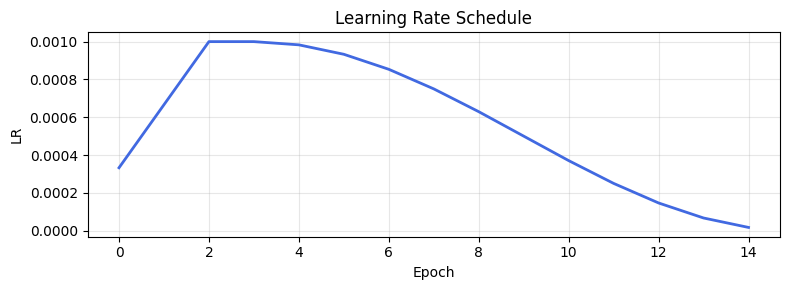

Selesai


In [20]:
# Custom Callback: Warmup + Cosine Decay Learning Rate
# Learning rate naik perlahan (warmup) lalu turun mengikuti kurva cosine

class WarmupCosineDecay(tf.keras.callbacks.Callback):
    def __init__(self, warmup_epochs=3, total_epochs=30,
                 max_lr=1e-3, min_lr=1e-6):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.total_epochs  = total_epochs
        self.max_lr        = max_lr
        self.min_lr        = min_lr
        self.lr_history    = []

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            lr = self.max_lr * (epoch + 1) / self.warmup_epochs
        else:
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (
                1.0 + np.cos(np.pi * progress)
            )
        tf.keras.backend.set_value(self.model.optimizer.learning_rate, float(lr))
        self.lr_history.append(float(lr))

    def plot_schedule(self):
        plt.figure(figsize=(8, 3))
        plt.plot(self.lr_history, color='royalblue', linewidth=2)
        plt.title('Learning Rate Schedule')
        plt.xlabel('Epoch'); plt.ylabel('LR'); plt.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

# Kurva LR
preview_cb = WarmupCosineDecay(warmup_epochs=3, total_epochs=PHASE1_EPOCHS,
                                max_lr=PHASE1_LR, min_lr=1e-6)
for e in range(PHASE1_EPOCHS):
    preview_cb.lr_history.append(
        PHASE1_LR * (e+1)/3 if e < 3 else
        1e-6 + 0.5*(PHASE1_LR-1e-6)*(1+np.cos(np.pi*(e-3)/(PHASE1_EPOCHS-3)))
    )
preview_cb.plot_schedule()
print("Selesai")
